In [3]:
import Pkg

required_pkgs = ["CSV", "DataFrames", "Plots"]

for pkg_name in required_pkgs
    if Base.find_package(pkg_name) === nothing
        println("Installing $(pkg_name)...")
        Pkg.add(pkg_name)
    end
end

println("Package check complete.")

Installing CSV...


   Resolving package versions...
    Updating `C:\Users\elbak\.julia\environments\v1.12\Project.toml`
  [336ed68f] + CSV v0.10.16
    Updating `C:\Users\elbak\.julia\environments\v1.12\Manifest.toml`
  [336ed68f] + CSV v0.10.16
  [944b1d66] + CodecZlib v0.7.8
  [34da2185] + Compat v4.18.1
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [48062228] + FilePathsBase v0.9.24
  [842dd82b] + InlineStrings v1.4.5
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [69de0a69] + Parsers v2.8.3
  [2dfb63ee] + PooledArrays v1.4.3
  [aea7be01] + PrecompileTools v1.3.3
  [91c51154] + SentinelArrays v1.4.9
  [3783bdb8] + TableTraits v1.0.1
  [bd369af6] + Tables v1.12.1
  [3bb67fe8] + TranscodingStreams v0.11.3
  [ea10d353] + WeakRefStrings v1.4.2
  [76eceee3] + WorkerUtilities v1.6.1
  [9fa8497b] + Future v1.11.0
  [a63ad114] + Mmap v1.11.0
  [83775a58] + Zlib_jll v1.3.1+2
Precompiling packages...
   1190.1 ms  ✓ Compiler
   1525.5 ms  ✓ Preferences
   1700.1 ms  ✓ CodeTrac

Installing DataFrames...


  26188.8 ms  ✓ CSV
  11 dependencies successfully precompiled in 59 seconds. 34 already precompiled.
   Resolving package versions...
   Installed StringManipulation ─ v0.4.4
    Updating `C:\Users\elbak\.julia\environments\v1.12\Project.toml`
  [a93c6f00] + DataFrames v1.8.1
    Updating `C:\Users\elbak\.julia\environments\v1.12\Manifest.toml`
  [a8cc5b0e] + Crayons v4.1.1
  [a93c6f00] + DataFrames v1.8.1
  [864edb3b] + DataStructures v0.19.3
  [41ab1584] + InvertedIndices v1.3.1
  [b964fa9f] + LaTeXStrings v1.4.0
  [e1d29d7a] + Missings v1.2.0
  [08abe8d2] + PrettyTables v3.2.3
  [189a3867] + Reexport v1.2.2
  [a2af1166] + SortingAlgorithms v1.2.2
  [10745b16] + Statistics v1.11.1
  [892a3eda] + StringManipulation v0.4.4
  [37e2e46d] + LinearAlgebra v1.12.0
  [e66e0078] + CompilerSupportLibraries_jll v1.3.0+1
  [4536629a] + OpenBLAS_jll v0.3.29+0
  [8e850b90] + libblastrampoline_jll v5.15.0+0
Precompiling packages...
   2506.0 ms  ✓ StringManipulation
  29406.8 ms  ✓ PrettyTables


Installing Plots...


  70598.6 ms  ✓ DataFrames
  3 dependencies successfully precompiled in 105 seconds. 54 already precompiled.
   Resolving package versions...
    Updating `C:\Users\elbak\.julia\environments\v1.12\Project.toml`
  [91a5bcdd] + Plots v1.41.6
    Updating `C:\Users\elbak\.julia\environments\v1.12\Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [d1d4a3ce] + BitFlags v0.1.9
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.1
  [f0e56b4a] + ConcurrentUtilities v2.5.1
  [d38c429a] + Contour v0.6.3
  [8bb1440f] + DelimitedFiles v1.9.1
  [ffbed154] + DocStringExtensions v0.9.5
  [460bff9d] + ExceptionUnwrapping v0.1.11
  [c87230d0] + FFMPEG v0.4.5
  [53c48c17] + FixedPointNumbers v0.8.5
  [1fa38f19] + Format v1.3.7
  [28b8d3ca] + GR v0.73.22
  [42e2da0e] + Grisu v1.0.2
  [cd3eb016] + HTTP v1.10.19
  [92d709cd] + IrrationalConstants v0.2.6
  [1019f520] + JLFzf v0.1.11
  [692b3bcd] + JLLWrappers v1.7.1
  [6

Package check complete.


  89057.3 ms  ✓ Plots
  93 dependencies successfully precompiled in 181 seconds. 113 already precompiled.


# Treated CoCulture: Data Load + Initial Plots

This notebook currently does two things:
1. Loads all treated coculture CSVs
2. Creates quick exploratory plots of cell area vs day

In [4]:
using CSV
using DataFrames
using Statistics
using Random
using Printf
using Plots

function find_project_root(start::AbstractString = pwd())
    current = abspath(start)
    while true
        if isdir(joinpath(current, "Datasets")) || isdir(joinpath(current, "Processed_Datasets"))
            return current
        end
        parent = dirname(current)
        if parent == current
            return abspath(start)
        end
        current = parent
    end
end

project_root = find_project_root()
processed_dir = joinpath(project_root, "Processed_Datasets", "Treated Coculture")
raw_dir = joinpath(project_root, "Datasets", "Treated Coculture")
data_dir = isdir(processed_dir) ? processed_dir : raw_dir

csv_files = sort(filter(path -> endswith(lowercase(path), ".csv"), readdir(data_dir; join=true)))
isempty(csv_files) && error("No CSV files found in $(data_dir)")

frames = DataFrame[]
for file_path in csv_files
    temp = CSV.read(file_path, DataFrame)

    if !("Image" in names(temp))
        continue
    end

    area_col_candidates = filter(c -> c != "Image", names(temp))
    isempty(area_col_candidates) && continue

    area_col = area_col_candidates[1]
    rename!(temp, area_col => "cell_area_um2")

    fname = basename(file_path)
    mix_match = match(r"measure_(\d+-\d+)", fname)
    mix_value = isnothing(mix_match) ? "unknown" : mix_match.captures[1]
    cell_line_value = occursin("cis", lowercase(fname)) ? "A2780cis" : "A2780"

    temp.mix = fill(mix_value, nrow(temp))
    temp.cell_line = fill(cell_line_value, nrow(temp))
    temp.source_file = fill(fname, nrow(temp))

    day_values = Vector{Union{Missing, Int}}(undef, nrow(temp))
    for (i, img) in enumerate(temp.Image)
        day_match = match(r"Day(\d+)", String(img))
        day_values[i] = isnothing(day_match) ? missing : parse(Int, day_match.captures[1])
    end
    temp.day = day_values

    select!(temp, ["Image", "cell_area_um2", "day", "mix", "cell_line", "source_file"])
    push!(frames, temp)
end

df = vcat(frames...; cols=:union)
dropmissing!(df, [:day, :cell_area_um2])
transform!(df, :day => ByRow(Int) => :day)
sort!(df, [:mix, :cell_line, :day])

loaded_files = DataFrame(loaded_files = basename.(csv_files))
display(loaded_files)
display(first(df, min(5, nrow(df))))

println(@sprintf("Rows loaded: %d", nrow(df)))
println("Data directory: " * data_dir)

Row,loaded_files
,String
1,measure_25-75A2780IC50tre1uM_2000Thres.csv
2,measure_25-75A2780cisIC50tre1uM_5000Thres.csv
3,measure_50-50A2780IC50tre1uM_2000Thres.csv
4,measure_50-50A2780cisIC50tre1uM_5000Thres.csv
5,measure_75-25A2780IC50tre1uM_2000Thres.csv
6,measure_75-25A2780cisIC50tre1uM_5000Thres.csv


Row,Image,cell_area_um2,day,mix,cell_line,source_file
,String,Float64,Int64,SubStrin…,String,String
1,25-75_A2780_20and30_IC50treat_Day1_TXR_Tile-0_A3.tif,44.0972,1,25-75,A2780,measure_25-75A2780IC50tre1uM_2000Thres.csv
2,25-75_A2780_20and30_IC50treat_Day1_TXR_Tile-0_A6.tif,156.033,1,25-75,A2780,measure_25-75A2780IC50tre1uM_2000Thres.csv
3,25-75_A2780_20and30_IC50treat_Day1_TXR_Tile-0_B3.tif,46.8271,1,25-75,A2780,measure_25-75A2780IC50tre1uM_2000Thres.csv
4,25-75_A2780_20and30_IC50treat_Day1_TXR_Tile-0_B6.tif,76.5931,1,25-75,A2780,measure_25-75A2780IC50tre1uM_2000Thres.csv
5,25-75_A2780_20and30_IC50treat_Day1_TXR_Tile-0_C3.tif,118.433,1,25-75,A2780,measure_25-75A2780IC50tre1uM_2000Thres.csv


Rows loaded: 3024
Data directory: d:\3_Research\CancerGrowthDynamics\Processed_Datasets\Treated Coculture


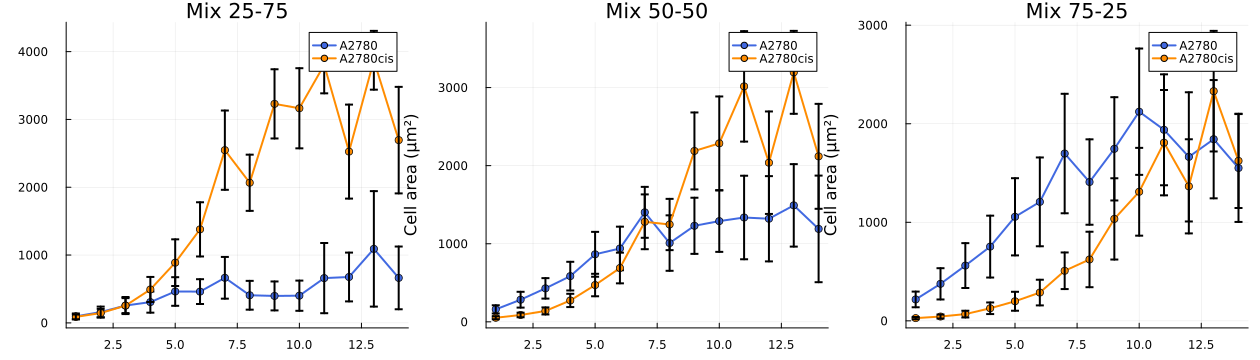

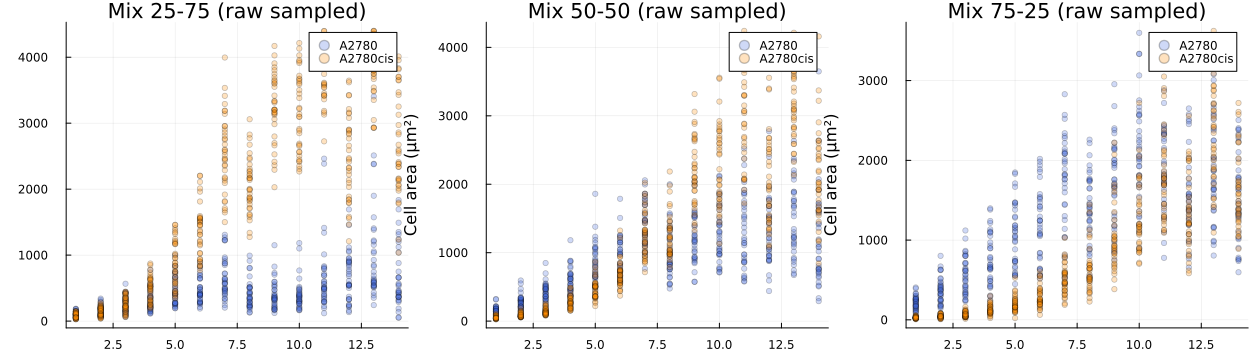

Row,mix,cell_line,day,mean_area_um2,sd_area_um2,n
,SubStrin…,String,Int64,Float64,Float64,Int64
1,25-75,A2780,1,95.9549,42.7741,36
2,25-75,A2780,2,159.292,80.2819,36
3,25-75,A2780,3,255.367,125.989,36
4,25-75,A2780,4,306.363,155.94,36
5,25-75,A2780,5,462.838,211.198,36
6,25-75,A2780,6,461.093,182.743,36
7,25-75,A2780,7,664.687,307.282,36
8,25-75,A2780,8,407.227,212.624,36
9,25-75,A2780,9,397.279,212.886,36


In [5]:
summary = combine(
    groupby(df, [:mix, :cell_line, :day]),
    :cell_area_um2 => mean => :mean_area_um2,
    :cell_area_um2 => std => :sd_area_um2,
    nrow => :n
)

mixes = sort(unique(summary.mix))
line_palette = [:royalblue, :darkorange]

plt1 = plot(
    layout = (1, length(mixes)),
    size = (420 * max(length(mixes), 1), 360),
    legend = :topright
)

for (idx, mix_value) in enumerate(mixes)
    s_mix = filter(:mix => ==(mix_value), summary)
    lines = sort(unique(s_mix.cell_line))
    for (j, line) in enumerate(lines)
        t = filter(:cell_line => ==(line), s_mix)
        sort!(t, :day)
        yerr = coalesce.(t.sd_area_um2, 0.0)
        plot!(
            plt1[idx],
            t.day,
            t.mean_area_um2;
            yerror = yerr,
            marker = :circle,
            linewidth = 2,
            color = line_palette[min(j, length(line_palette))],
            label = line
        )
    end
    title!(plt1[idx], "Mix $(mix_value)")
    xlabel!(plt1[idx], "Day")
    ylabel!(plt1[idx], "Cell area (μm²)")
end

display(plt1)

sample_n = min(3000, nrow(df))
sample_idx = sample_n < nrow(df) ? randperm(nrow(df))[1:sample_n] : collect(1:nrow(df))
df_plot = df[sample_idx, :]

plt2 = plot(
    layout = (1, length(mixes)),
    size = (420 * max(length(mixes), 1), 360),
    legend = :topright
)

for (idx, mix_value) in enumerate(mixes)
    d_mix = filter(:mix => ==(mix_value), df_plot)
    lines = sort(unique(d_mix.cell_line))
    for (j, line) in enumerate(lines)
        t = filter(:cell_line => ==(line), d_mix)
        scatter!(
            plt2[idx],
            t.day,
            t.cell_area_um2;
            markersize = 3,
            markeralpha = 0.25,
            color = line_palette[min(j, length(line_palette))],
            label = line
        )
    end
    title!(plt2[idx], "Mix $(mix_value) (raw sampled)")
    xlabel!(plt2[idx], "Day")
    ylabel!(plt2[idx], "Cell area (μm²)")
end

display(plt2)
display(first(summary, min(12, nrow(summary))))